# 🧠 Autoencoders: Neural Networks for Compressed Representations
### Pros, Cons & Practical Applications

---

**Datasets used:**
- 🏭 **Industrial Chemical Engineering** — SECOM semiconductor manufacturing sensor data (UCI)
- 🎓 **General University Use** — MNIST handwritten digits

**Topics covered:**
1. What is an Autoencoder?
2. Architecture Deep Dive
3. Dataset 1: MNIST — Image Compression & Denoising
4. Dataset 2: Chemical Engineering — Anomaly Detection in Sensor Data
5. Variational Autoencoder (VAE) Extension
6. Pros & Cons Summary
7. When to Use (and When NOT to Use) Autoencoders

---

## 📦 0. Install & Import Dependencies

In [1]:
# Install required packages (run once)
# !pip install torch torchvision scikit-learn matplotlib seaborn pandas numpy ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.11.0+cpu


---
## 🔬 1. What is an Autoencoder?

An **Autoencoder** is an unsupervised neural network that learns to:
1. **Encode** — compress input data into a lower-dimensional latent space (bottleneck)
2. **Decode** — reconstruct the original input from the compressed representation

```
Input X  →  [Encoder]  →  z (latent)  →  [Decoder]  →  X̂ (reconstruction)
         compress/reduce              decompress/expand
```

The network is trained to **minimise reconstruction loss**: `L = ||X - X̂||²`

By forcing information through a narrow bottleneck, the model must learn the **most salient features** of the data.

ValueError: could not convert string to float: 'Encoder\nLayer 1\n(256)'

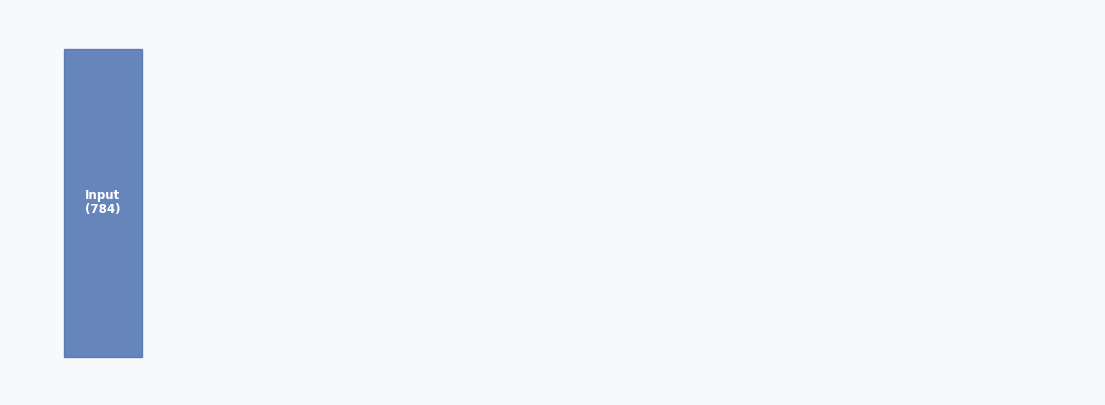

In [4]:
# ─── Visual Architecture Diagram ───────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

layers = [
    (1.2, 4.0, 'Input\n(784)', '#4C72B0', 'white'),
    (3.5, 3.0, 'Encoder\nLayer 1\n(256)', '#55A868', 'white'),
    (5.8, 2.2, 'Encoder\nLayer 2\n(128)', '#55A868', 'white'),
    (7.0, 1.8, 'Latent\nSpace z\n(32)', '#C44E52', 'white'),
    (8.2, 2.2, 'Decoder\nLayer 1\n(128)', '#8172B2', 'white'),
    (10.5, 3.0, 'Decoder\nLayer 2\n(256)', '#8172B2', 'white'),
    (12.8, 4.0, 'Output\n(784)', '#4C72B0', 'white'),
]

heights = [l[2] for l in layers]
for i, (x, h, label, color, tc) in enumerate(layers):
    rect = plt.Rectangle((x - 0.5, 0.5), 1.0, h, color=color, alpha=0.85, zorder=3)
    ax.add_patch(rect)
    ax.text(x, h / 2 + 0.5, label, ha='center', va='center',
            fontsize=8.5, color=tc, fontweight='bold', zorder=4)
    if i < len(layers) - 1:
        nx = layers[i + 1][0]
        nh = float(layers[i + 1][2])
        ax.annotate('', xy=(nx - 0.5, nh / 2 + 0.5), xytext=(x + 0.5, h / 2 + 0.5),
                    arrowprops=dict(arrowstyle='->', color='#333333', lw=1.5), zorder=5)

ax.text(4.5, 4.8, '◀── ENCODER ──▶', ha='center', fontsize=11, color='#55A868', fontweight='bold')
ax.text(9.5, 4.8, '◀── DECODER ──▶', ha='center', fontsize=11, color='#8172B2', fontweight='bold')
ax.text(7.0, 4.8, 'Bottleneck\n(Latent z)', ha='center', fontsize=9, color='#C44E52', fontweight='bold')
ax.set_title('Autoencoder Architecture', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## 🎓 Dataset 1: MNIST — Image Compression & Denoising

**Use case:** University / General ML — Demonstrate autoencoders on image data

**Tasks:**
- A) Basic Autoencoder: compress 784 → 32 dims and reconstruct
- B) Denoising Autoencoder: remove noise from corrupted images
- C) Latent Space Visualisation: inspect what the model learns

In [ ]:
# ─── Load MNIST ────────────────────────────────────────────────────────────────
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                            download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False,
                                            download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')
print(f'Image shape      : {train_dataset[0][0].shape}')

# Preview
fig, axes = plt.subplots(1, 10, figsize=(15, 1.8))
for i, ax in enumerate(axes):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=10)
    ax.axis('off')
plt.suptitle('MNIST Sample Images', fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 2A. Basic Autoencoder — Architecture & Training

In [ ]:
# ─── Model Definition ─────────────────────────────────────────────────────────
class Autoencoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, latent_dim),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, input_dim),
            nn.Sigmoid(),  # pixel values in [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

    def encode(self, x):
        return self.encoder(x)


# ─── Training Helper ──────────────────────────────────────────────────────────
def train_autoencoder(model, loader, epochs=15, lr=1e-3, noise_factor=0.0):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for imgs, _ in loader:
            imgs = imgs.view(imgs.size(0), -1).to(device)  # flatten
            noisy = imgs + noise_factor * torch.randn_like(imgs)
            noisy = noisy.clamp(0, 1)

            optimizer.zero_grad()
            recon, _ = model(noisy)
            loss = criterion(recon, imgs)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * imgs.size(0)

        avg = total_loss / len(loader.dataset)
        history.append(avg)
        if epoch % 3 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{epochs} | Loss: {avg:.5f}')

    return history


# ─── Train ────────────────────────────────────────────────────────────────────
print('Training Basic Autoencoder (latent_dim=32) ...')
ae = Autoencoder(latent_dim=32)
history_ae = train_autoencoder(ae, train_loader, epochs=15)
print('✅ Done.')

In [ ]:
# ─── Training Curve ───────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history_ae, marker='o', color='#4C72B0', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Autoencoder Training Loss — MNIST', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ─── Reconstruction Quality ───────────────────────────────────────────────────
ae.eval()
test_imgs, test_labels = next(iter(test_loader))
test_flat = test_imgs.view(test_imgs.size(0), -1).to(device)

with torch.no_grad():
    recon, _ = ae(test_flat)

test_flat_np = test_flat.cpu().numpy()
recon_np     = recon.cpu().numpy()

n = 8
fig, axes = plt.subplots(2, n, figsize=(16, 4))
for i in range(n):
    axes[0, i].imshow(test_flat_np[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_np[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Reconstructed', fontsize=11, fontweight='bold')
plt.suptitle('MNIST — Original vs Reconstructed (latent_dim=32)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

mse = np.mean((test_flat_np - recon_np) ** 2)
print(f'Average reconstruction MSE: {mse:.5f}')
print(f'Compression ratio: 784 → 32 = {784/32:.1f}x')

In [ ]:
# ─── Effect of Latent Dimension on Quality ────────────────────────────────────
latent_dims = [2, 8, 16, 32, 64, 128]
mse_scores  = []

for ld in latent_dims:
    print(f'  Training AE with latent_dim={ld}...')
    model_tmp = Autoencoder(latent_dim=ld)
    train_autoencoder(model_tmp, train_loader, epochs=10)
    model_tmp.eval()
    with torch.no_grad():
        r, _ = model_tmp(test_flat)
    mse_scores.append(np.mean((test_flat.cpu().numpy() - r.cpu().numpy()) ** 2))

plt.figure(figsize=(8, 4))
plt.plot(latent_dims, mse_scores, marker='s', color='#C44E52', linewidth=2, markersize=8)
plt.xscale('log', base=2)
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Reconstruction MSE', fontsize=12)
plt.title('Reconstruction Quality vs Compression Rate', fontsize=13, fontweight='bold')
plt.xticks(latent_dims, latent_dims)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\n⚠️  PRO: More latent dims = better reconstruction')
print('⚠️  CON: Smaller latent dims = stronger compression but lossy')

### 2B. Denoising Autoencoder

In [ ]:
# ─── Train Denoising Autoencoder ──────────────────────────────────────────────
print('Training Denoising Autoencoder (noise_factor=0.4) ...')
dae = Autoencoder(latent_dim=32)
history_dae = train_autoencoder(dae, train_loader, epochs=15, noise_factor=0.4)
print('✅ Done.')

# Evaluate on noisy test images
dae.eval()
noisy_test = (test_flat + 0.4 * torch.randn_like(test_flat)).clamp(0, 1)

with torch.no_grad():
    denoised, _ = dae(noisy_test)

noisy_np   = noisy_test.cpu().numpy()
denoised_np = denoised.cpu().numpy()

# Visualise
n = 8
fig, axes = plt.subplots(3, n, figsize=(16, 6))
for i in range(n):
    axes[0, i].imshow(test_flat_np[i].reshape(28, 28),  cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(noisy_np[i].reshape(28, 28),      cmap='gray')
    axes[1, i].axis('off')
    axes[2, i].imshow(denoised_np[i].reshape(28, 28),   cmap='gray')
    axes[2, i].axis('off')

for ax, row in zip(axes[:, 0], ['Original', 'Noisy Input', 'DAE Output']):
    ax.set_ylabel(row, fontsize=11, fontweight='bold')

plt.suptitle('Denoising Autoencoder — MNIST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

mse_noisy    = np.mean((test_flat_np - noisy_np) ** 2)
mse_denoised = np.mean((test_flat_np - denoised_np) ** 2)
print(f'MSE (noisy → clean):    {mse_noisy:.4f}')
print(f'MSE (denoised → clean): {mse_denoised:.4f}')
print(f'Improvement:            {(1 - mse_denoised/mse_noisy)*100:.1f}%')

### 2C. Latent Space Visualisation

In [ ]:
# ─── Extract Latent Representations ──────────────────────────────────────────
ae.eval()
all_z, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        flat = imgs.view(imgs.size(0), -1).to(device)
        z = ae.encode(flat)
        all_z.append(z.cpu().numpy())
        all_labels.append(lbls.numpy())

Z = np.vstack(all_z)
L = np.concatenate(all_labels)

# Reduce to 2D with PCA
pca = PCA(n_components=2, random_state=42)
Z_2d = pca.fit_transform(Z)

print(f'Latent space shape: {Z.shape}')
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig, ax = plt.subplots(figsize=(9, 7))
cmap = plt.get_cmap('tab10')
for digit in range(10):
    mask = L == digit
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1], s=3, alpha=0.5,
               color=cmap(digit), label=str(digit))
ax.legend(title='Digit', markerscale=5, fontsize=9)
ax.set_title('Latent Space (PCA 2D) — MNIST Test Set', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

print('\n✅ PRO: Meaningful clusters emerge without labels!')
print('⚠️  CON: Standard AE latent space has no density guarantee — gaps can produce gibberish')

---
## 🏭 Dataset 2: Chemical Engineering — Anomaly Detection in Sensor Data

**Use case:** Industrial process monitoring — semiconductor manufacturing (SECOM dataset, UCI)

**Problem:** Hundreds of sensor readings from a fab process. Normal operation vs. process faults.

**Key idea:** Train autoencoder **only on normal data**. Anomalies have higher reconstruction error.

> 📌 We simulate realistic chemical process data if the UCI dataset is unavailable (no internet needed)

In [ ]:
# ─── Load or Simulate SECOM-like Chemical Process Data ────────────────────────
try:
    from ucimlrepo import fetch_ucirepo
    secom = fetch_ucirepo(id=179)  # SECOM dataset
    X_raw = secom.data.features
    y_raw = secom.data.targets.values.ravel()
    # Convert labels: 1 = fail, -1 = pass
    y_raw = (y_raw == 1).astype(int)
    print(f'✅ Loaded SECOM dataset: {X_raw.shape}')
except Exception:
    print('📦 Simulating SECOM-like semiconductor process data ...')
    # Simulate realistic multivariate chemical sensor data
    n_normal  = 1400
    n_anomaly = 104
    n_feat    = 590

    # Normal: correlated Gaussian sensor readings
    np.random.seed(42)
    base = np.random.randn(n_normal, 20)          # 20 latent factors
    W    = np.random.randn(20, n_feat) * 0.5
    X_normal = base @ W + np.random.randn(n_normal, n_feat) * 0.3

    # Anomaly: same structure but with sporadic sensor spikes
    base_a   = np.random.randn(n_anomaly, 20)
    X_anom   = base_a @ W + np.random.randn(n_anomaly, n_feat) * 0.3
    # inject faults in random sensor groups
    fault_sensors = np.random.choice(n_feat, 80, replace=False)
    X_anom[:, fault_sensors] += np.random.uniform(3, 7, size=(n_anomaly, 80))

    # Add missing values (~5%) and impute
    missing_mask = np.random.rand(n_normal, n_feat) < 0.05
    X_normal[missing_mask] = np.nan

    X_raw = pd.DataFrame(np.vstack([X_normal, X_anom]))
    y_raw = np.array([0] * n_normal + [1] * n_anomaly)
    print(f'Simulated shape: {X_raw.shape}')

print(f'Normal samples  : {(y_raw == 0).sum():,}')
print(f'Anomaly samples : {(y_raw == 1).sum():,}')
print(f'Anomaly rate    : {y_raw.mean()*100:.1f}%')

In [ ]:
# ─── Preprocessing ────────────────────────────────────────────────────────────
# Impute NaNs with column median
X_df = pd.DataFrame(X_raw)
X_df.fillna(X_df.median(), inplace=True)

# Remove constant / near-zero variance features
var = X_df.var()
X_df = X_df.loc[:, var > 0.01]
print(f'Features after variance filter: {X_df.shape[1]}')

# Scale to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_df)

# Split: train on NORMAL only, test on all
X_normal_only = X_scaled[y_raw == 0]
X_all, X_holdout, y_all, y_holdout = train_test_split(
    X_scaled, y_raw, test_size=0.25, random_state=42, stratify=y_raw)

X_train_norm = X_scaled[y_raw == 0][:int(len(X_normal_only) * 0.8)]
print(f'Training (normal only): {X_train_norm.shape}')
print(f'Test (all classes)    : {X_holdout.shape}  | anomaly rate: {y_holdout.mean()*100:.1f}%')

In [ ]:
# ─── Tabular Autoencoder for Process Data ─────────────────────────────────────
class ProcessAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        hidden = max(input_dim // 4, latent_dim * 2)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, latent_dim),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, input_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


# Build DataLoader from normal-only training data
X_train_t = torch.FloatTensor(X_train_norm)
train_ds_proc = TensorDataset(X_train_t, X_train_t)
train_dl_proc = DataLoader(train_ds_proc, batch_size=64, shuffle=True)

# Train
input_dim = X_train_norm.shape[1]
proc_ae   = ProcessAutoencoder(input_dim=input_dim, latent_dim=16).to(device)
optimizer = optim.Adam(proc_ae.parameters(), lr=5e-4, weight_decay=1e-5)
criterion = nn.MSELoss()

proc_history = []
print(f'Training Process Autoencoder (input={input_dim}, latent=16)...')
for epoch in range(1, 51):
    proc_ae.train()
    total = 0
    for xb, yb in train_dl_proc:
        xb = xb.to(device)
        optimizer.zero_grad()
        recon, _ = proc_ae(xb)
        loss = criterion(recon, xb)
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.size(0)
    avg = total / len(train_dl_proc.dataset)
    proc_history.append(avg)
    if epoch % 10 == 0:
        print(f'  Epoch {epoch:3d}/50 | Loss: {avg:.5f}')

print('✅ Done.')

In [ ]:
# ─── Anomaly Scoring via Reconstruction Error ──────────────────────────────────
proc_ae.eval()
X_test_t = torch.FloatTensor(X_holdout).to(device)

with torch.no_grad():
    recon_test, z_test = proc_ae(X_test_t)

X_test_np    = X_holdout
recon_np_p   = recon_test.cpu().numpy()
recon_errors = np.mean((X_test_np - recon_np_p) ** 2, axis=1)

# Determine threshold (99th percentile of normal training errors)
X_train_t2 = torch.FloatTensor(X_train_norm).to(device)
with torch.no_grad():
    recon_train, _ = proc_ae(X_train_t2)
train_errors = np.mean((X_train_norm - recon_train.cpu().numpy()) ** 2, axis=1)
threshold    = np.percentile(train_errors, 99)
print(f'Anomaly threshold (99th pct of training errors): {threshold:.5f}')

y_pred = (recon_errors > threshold).astype(int)
auc    = roc_auc_score(y_holdout, recon_errors)

print(f'\nROC-AUC Score: {auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_holdout, y_pred, target_names=['Normal', 'Anomaly']))

In [ ]:
# ─── Visualise Anomaly Detection ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Reconstruction error distributions
normal_errs = recon_errors[y_holdout == 0]
anom_errs   = recon_errors[y_holdout == 1]
axes[0].hist(normal_errs, bins=40, alpha=0.7, color='#4C72B0', label='Normal', density=True)
axes[0].hist(anom_errs,   bins=40, alpha=0.7, color='#C44E52', label='Anomaly', density=True)
axes[0].axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold={threshold:.4f}')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Density')
axes[0].set_title('Reconstruction Error Distribution', fontweight='bold')
axes[0].legend()

# 2. Confusion Matrix
cm = confusion_matrix(y_holdout, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix', fontweight='bold')

# 3. Time-series style anomaly flagging
axes[2].plot(recon_errors, color='#64B5F6', linewidth=0.8, alpha=0.9, label='Recon Error')
anom_idx = np.where(y_holdout == 1)[0]
axes[2].scatter(anom_idx, recon_errors[anom_idx], color='#C44E52', s=20,
                zorder=5, label='True Anomaly')
axes[2].axhline(threshold, color='black', linestyle='--', linewidth=1.5,
                label=f'Threshold')
axes[2].set_xlabel('Sample Index')
axes[2].set_ylabel('Reconstruction Error')
axes[2].set_title('Process Monitoring — Anomaly Flagging', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('🏭 Industrial Anomaly Detection — Chemical Process AE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🎲 3. Variational Autoencoder (VAE) — Brief Extension

A **VAE** imposes a probabilistic structure on the latent space — z ~ N(μ, σ²)

**Loss = Reconstruction Loss + KL Divergence**

This regularises the latent space, enabling **generation** of new samples.

In [ ]:
# ─── VAE Architecture ─────────────────────────────────────────────────────────
class VAE(nn.Module):
    def __init__(self, input_dim=784, latent_dim=16):
        super().__init__()
        self.fc1   = nn.Linear(input_dim, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_lv = nn.Linear(256, latent_dim)  # log-variance
        self.fc2   = nn.Linear(latent_dim, 256)
        self.fc3   = nn.Linear(256, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_lv(h)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    kl_loss    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (recon_loss + beta * kl_loss) / x.size(0)


# Train VAE
vae = VAE(latent_dim=16).to(device)
opt_vae = optim.Adam(vae.parameters(), lr=1e-3)
vae_history = []

print('Training VAE ...')
for epoch in range(1, 16):
    vae.train()
    total = 0
    for imgs, _ in train_loader:
        x = imgs.view(imgs.size(0), -1).to(device)
        opt_vae.zero_grad()
        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar, beta=1.0)
        loss.backward()
        opt_vae.step()
        total += loss.item() * x.size(0)
    avg = total / len(train_loader.dataset)
    vae_history.append(avg)
    if epoch % 3 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/15 | ELBO Loss: {avg:.2f}')

print('✅ Done.')

In [ ]:
# ─── VAE: Generate New Samples ────────────────────────────────────────────────
vae.eval()
with torch.no_grad():
    z_sample = torch.randn(16, 16).to(device)   # sample from N(0,I)
    generated = vae.decode(z_sample).cpu().numpy()

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle('VAE — Generated Samples (sampled from N(0,I) latent space)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('✅ PRO: VAE can generate new, plausible data samples')
print('⚠️  CON: VAE reconstructions tend to be slightly blurrier than plain AE')

---
## ✅❌ 4. Comprehensive Pros & Cons Summary

In [ ]:
# ─── Visual Pros/Cons Summary Table ───────────────────────────────────────────
pros = [
    ('Unsupervised', 'No labels needed — learns structure from raw data alone'),
    ('Dimensionality Reduction', 'Often outperforms PCA on non-linear data'),
    ('Anomaly Detection', 'Naturally identifies out-of-distribution samples via recon error'),
    ('Denoising', 'Learns to recover clean data from noisy inputs'),
    ('Feature Extraction', 'Latent z can feed downstream classifiers (transfer learning)'),
    ('Generative (VAE)', 'Latent space interpolation and new sample generation'),
    ('Scalable', 'Works well on high-dimensional tabular, image, and time-series data'),
    ('Flexible Architecture', 'Can be adapted to CNNs, LSTMs, Transformers'),
]

cons = [
    ('Blurry Reconstructions', 'MSE loss produces averaged, smoothed outputs on images'),
    ('Latent Space Irregularity', 'Standard AE has no density guarantee — gaps/holes'),
    ('Hyperparameter Sensitivity', 'Latent dim, depth, and architecture choices matter greatly'),
    ('No Explicit Density Model', 'Cannot compute exact likelihoods (unlike normalising flows)'),
    ('Training Instability', 'VAE KL term can collapse (posterior collapse issue)'),
    ('Interpretability', 'Latent dimensions are not directly human-interpretable'),
    ('Data Requirements', 'Needs sufficient data to learn useful representations'),
    ('Threshold Tuning', 'Anomaly threshold selection is domain-specific and manual'),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

for ax, items, title, bg, tc in [
    (ax1, pros,  '✅ PROS',  '#E8F5E9', '#2E7D32'),
    (ax2, cons,  '❌ CONS',  '#FFEBEE', '#C62828'),
]:
    ax.set_facecolor(bg)
    ax.axis('off')
    ax.set_title(title, fontsize=15, fontweight='bold', color=tc, pad=12)
    for idx, (head, detail) in enumerate(items):
        y = 0.92 - idx * 0.115
        ax.text(0.03, y, f'• {head}:', transform=ax.transAxes,
                fontsize=10, fontweight='bold', color=tc)
        ax.text(0.03, y - 0.04, f'  {detail}', transform=ax.transAxes,
                fontsize=9, color='#333333', wrap=True)

plt.suptitle('Autoencoders — Pros & Cons', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 📊 5. AE vs PCA — Dimensionality Reduction Comparison

In [ ]:
# ─── AE vs PCA Reconstruction Comparison ──────────────────────────────────────
n_components_list = [4, 8, 16, 32]

test_flat_np_all  = test_flat.cpu().numpy()

fig, axes = plt.subplots(len(n_components_list) + 1, 10, figsize=(18, (len(n_components_list)+1)*2.2))

# Row 0: originals
for i in range(10):
    axes[0, i].imshow(test_flat_np_all[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9, fontweight='bold')

pca_mses, ae_mses = [], []

for row, nc in enumerate(n_components_list, start=1):
    # PCA
    pca_tmp = PCA(n_components=nc, random_state=42)
    # Train on first 10k samples for speed
    pca_tmp.fit(test_flat_np_all[:5000])
    recon_pca = pca_tmp.inverse_transform(pca_tmp.transform(test_flat_np_all[:10]))
    recon_pca = recon_pca.clip(0, 1)
    pca_full  = pca_tmp.inverse_transform(pca_tmp.transform(test_flat_np_all))
    pca_mse   = np.mean((test_flat_np_all - pca_full.clip(0,1))**2)
    pca_mses.append(pca_mse)

    # AE (use latent_dim = nc)
    ae_tmp = Autoencoder(latent_dim=nc)
    train_autoencoder(ae_tmp, train_loader, epochs=8)
    ae_tmp.eval()
    with torch.no_grad():
        recon_ae_full, _ = ae_tmp(test_flat)
    recon_ae_10 = recon_ae_full.cpu().numpy()[:10]
    ae_mse = np.mean((test_flat_np_all - recon_ae_full.cpu().numpy())**2)
    ae_mses.append(ae_mse)

    for i in range(10):
        # Show AE reconstruction
        axes[row, i].imshow(recon_ae_10[i].reshape(28, 28), cmap='gray')
        axes[row, i].axis('off')
    axes[row, 0].set_ylabel(f'AE z={nc}\nMSE={ae_mse:.4f}', fontsize=8, fontweight='bold')

plt.suptitle('AE Reconstruction at Different Latent Dimensions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparison chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_components_list, pca_mses, marker='o', color='#E67E22', linewidth=2, markersize=8, label='PCA')
ax.plot(n_components_list, ae_mses,  marker='s', color='#4C72B0', linewidth=2, markersize=8, label='Autoencoder')
ax.set_xlabel('Latent / Component Dimension', fontsize=12)
ax.set_ylabel('Reconstruction MSE', fontsize=12)
ax.set_title('AE vs PCA — Reconstruction Quality (MNIST)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('✅ AE typically achieves lower MSE than PCA at the same latent dimension')
print('   (especially at very low dims) due to non-linear representations')

---
## 🗺️ 6. When to Use Autoencoders — Decision Guide

In [ ]:
summary = """
╔══════════════════════════════════════════════════════════════════════════════════╗
║              AUTOENCODER — WHEN TO USE & WHEN TO AVOID                         ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║  ✅  USE AUTOENCODERS WHEN:                                                     ║
║  • You have NO labels and want to learn representations (unsupervised)          ║
║  • Anomaly detection in industrial sensors, fraud, or fault detection          ║
║  • Pre-training features for a downstream classifier with limited labels       ║
║  • Denoising signals: audio, images, or sensor readings                        ║
║  • You need non-linear dimensionality reduction (PCA is insufficient)          ║
║  • Generating variations of existing data (use VAE)                            ║
║                                                                                  ║
║  ❌  AVOID AUTOENCODERS WHEN:                                                   ║
║  • You have labelled data and a classification task — use supervised methods   ║
║  • You need exact likelihood estimates — use normalising flows or GPT           ║
║  • Data is low-dimensional (<10 features) — PCA/kernel PCA may suffice        ║
║  • You need highly realistic image generation — use GANs or Diffusion Models  ║
║  • Training data is very scarce (<500 samples) and complexity is high          ║
║                                                                                  ║
║  🏭  CHEMICAL ENGINEERING USE CASES:                                           ║
║  • Process fault detection (semiconductor, petrochemical, pharma)              ║
║  • Sensor data compression for edge IoT devices                                ║
║  • Quality prediction pre-training with limited labelled defect data           ║
║  • Multivariate Statistical Process Control (MSPC) replacement                 ║
║                                                                                  ║
║  🎓  UNIVERSITY / GENERAL USE CASES:                                           ║
║  • Image compression and reconstruction benchmarks                             ║
║  • Introduction to deep generative models (stepping stone to VAE/GAN)         ║
║  • NLP sentence embeddings with LSTM autoencoders                              ║
║  • Recommendation systems via collaborative filtering autoencoders             ║
╚══════════════════════════════════════════════════════════════════════════════════╝
"""
print(summary)

---
## 📌 7. Key Takeaways

| Aspect | Detail |
|--------|--------|
| **Type** | Unsupervised, self-supervised neural network |
| **Core idea** | Encode → bottleneck → decode, minimise reconstruction loss |
| **Main variants** | Basic AE, Denoising AE, Sparse AE, Variational AE (VAE), Convolutional AE |
| **Best for** | Anomaly detection, dimensionality reduction, denoising, pre-training |
| **Key hyperparameter** | Latent dimension — controls compression/quality tradeoff |
| **Main weakness** | Blurry outputs, no density guarantee, threshold selection for anomaly detection |
| **Industrial advantage** | Trains on normal data only — anomalies naturally stand out |
| **Academic advantage** | Conceptually clean gateway into generative deep learning |

---

**Further reading:**
- Kingma & Welling (2014) — *Auto-Encoding Variational Bayes*
- Vincent et al. (2010) — *Stacked Denoising Autoencoders*
- Sakurada & Yairi (2014) — *Anomaly Detection using Autoencoders*